<a href="https://colab.research.google.com/github/Karishmaaa22/ML-safety/blob/main/Copy_of_Pedestrian_model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/Data2/train"
test_path = "/content/drive/MyDrive/Data2/test"

In [ ]:
train_rgb_path = train_path + "/rgb-front"
test_rgb_path = test_path + "/rgb-front"

In [ ]:
import pandas as pd
labels_train = pd.read_csv(train_path + "/labels.csv")
labels_test = pd.read_csv(test_path + "/labels.csv")

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
import os
print(os.listdir(train_path))

['imu.feather', 'sim.log', 'carla.log', 'labels.csv', 'actions.feather', 'collisions.feather', 'weather.feather', 'gnss.feather', 'labels.feather', 'rgb-front', '.hydra', 'segmentation-front']


In [ ]:
print(os.listdir(train_rgb_path)[:5])

['044820.jpg', '010380.jpg', '034450.jpg', '006810.jpg', '044020.jpg']


In [ ]:
print(labels_train.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  


In [ ]:
train_images = os.listdir(train_rgb_path)
test_images = os.listdir(test_rgb_path)
print("Number of Training Images:", len(train_images))
print("Number of Test Images:", len(test_images))

Number of Training Images: 7200
Number of Test Images: 3600


In [ ]:
labels=["has_pedestrian","has_traffic_light","has_vehicle"]
for label in labels:
  print(f"Class Distribution: {label}")
  distribution =(labels_train[label].value_counts(normalize=True)*100)
  print(distribution)

Class Distribution: has_pedestrian
has_pedestrian
False    76.138889
True     23.861111
Name: proportion, dtype: float64
Class Distribution: has_traffic_light
has_traffic_light
True     73.277778
False    26.722222
Name: proportion, dtype: float64
Class Distribution: has_vehicle
has_vehicle
True     75.805556
False    24.194444
Name: proportion, dtype: float64


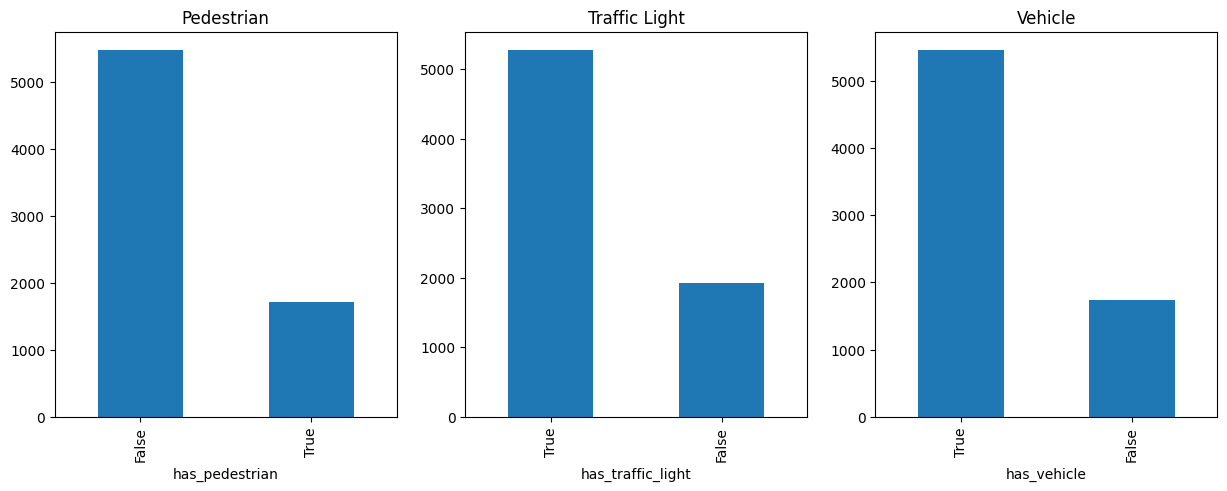

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15,5))
labels_train['has_pedestrian'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Pedestrian'
)
labels_train['has_traffic_light'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='Traffic Light'
)
labels_train['has_vehicle'].value_counts().plot(
    kind='bar',
    ax=axes[2],
    title='Vehicle'
)
plt.show()

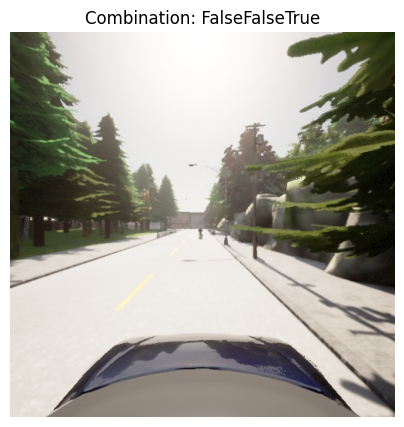

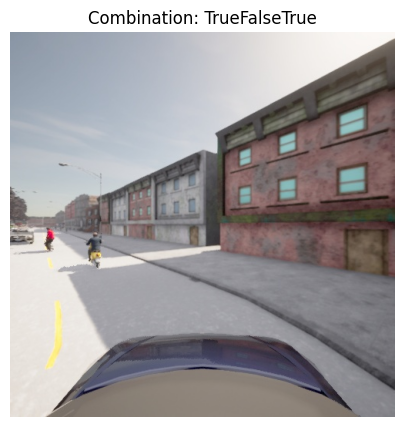

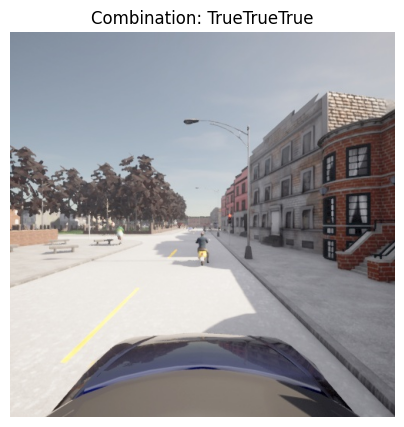

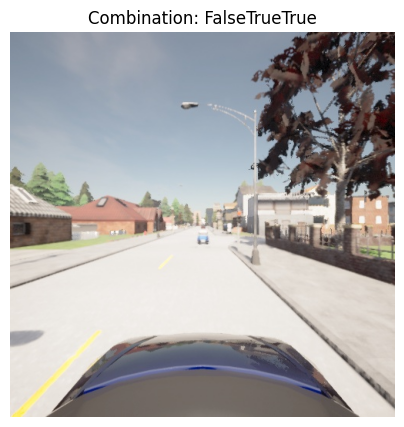

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Data2/train/rgb-front/000290.jpg'

In [ ]:
from PIL import Image
labels_train['combination'] = (
    labels_train['has_pedestrian'].astype(str)
    + labels_train['has_traffic_light'].astype(str)
    + labels_train['has_vehicle'].astype(str)
)
unique_combinations = labels_train['combination'].unique()
for combo in unique_combinations:
    sample = labels_train[
        labels_train['combination'] == combo
    ].iloc[0]
    image_name = f"{sample['frame']:06d}.jpg"
    image_path = os.path.join(
        train_rgb_path,
        image_name
    )
    image = Image.open(image_path)
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(f"Combination: {combo}")
    plt.axis('off')
    plt.show()

In [ ]:

from torchvision import models
import torch.nn as nn
def create_model():
    model = models.resnet18(
        pretrained=True
    )
    model.fc = nn.Linear(512, 1)
    return model
model = create_model()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)
batch_size = 32
epochs = 5

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 126MB/s]


In [ ]:
from torch.utils.data import Dataset
class CarlaDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_dir,
        label_column,
        transform=None
    ):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.label_column = label_column
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_name = f"{row['frame']:06d}.jpg"
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
        image = Image.open(
            image_path
        ).convert("RGB")
        label = torch.tensor(
            row[self.label_column],
            dtype=torch.float32
        )
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
import torchvision.transforms as transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using Device:", device)

Using Device: cuda



Training Model For: has_pedestrian


100%|██████████| 450/450 [15:15<00:00,  2.03s/it]


Epoch [1/5] | Train Loss: 0.4611 | Val Loss: 0.5120


100%|██████████| 450/450 [00:49<00:00,  9.01it/s]


Epoch [2/5] | Train Loss: 0.3271 | Val Loss: 0.7290


...

Epoch [3/5] | Train Loss: 0.2370 | Val Loss: 0.5379


100%|██████████| 450/450 [00:51<00:00,  8.71it/s]


Epoch [4/5] | Train Loss: 0.1570 | Val Loss: 0.7492


100%|██████████| 450/450 [00:51<00:00,  8.73it/s]


Epoch [5/5] | Train Loss: 0.1187 | Val Loss: 0.6791


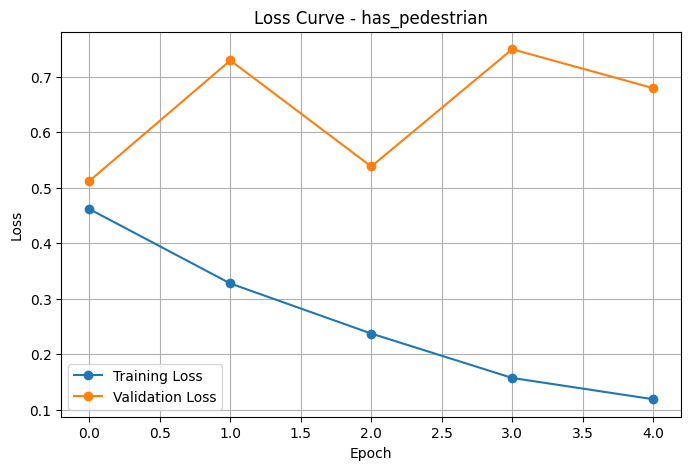

Saved: has_pedestrian_model.pth

Training Model For: has_traffic_light


100%|██████████| 450/450 [00:50<00:00,  8.89it/s]


Epoch [1/5] | Train Loss: 0.1496 | Val Loss: 0.2637


100%|██████████| 450/450 [00:48<00:00,  9.25it/s]


Epoch [2/5] | Train Loss: 0.0594 | Val Loss: 0.2608


...

Epoch [3/5] | Train Loss: 0.0362 | Val Loss: 0.2567


100%|██████████| 450/450 [00:47<00:00,  9.38it/s]


Epoch [4/5] | Train Loss: 0.0270 | Val Loss: 0.2692


100%|██████████| 450/450 [00:48<00:00,  9.33it/s]


Epoch [5/5] | Train Loss: 0.0316 | Val Loss: 0.1936


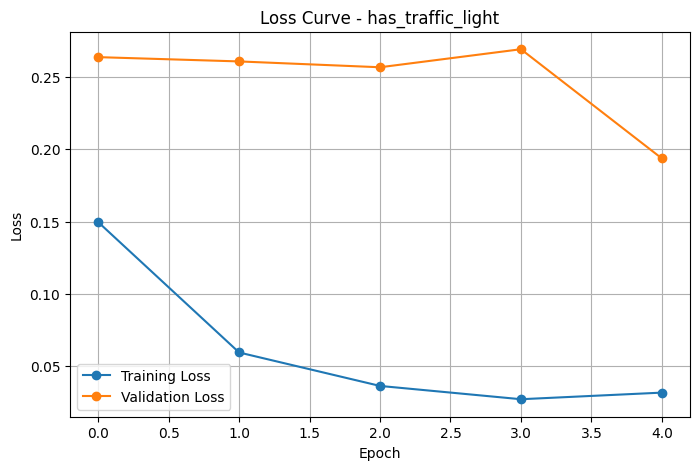

Saved: has_traffic_light_model.pth

Training Model For: has_vehicle


100%|██████████| 450/450 [00:48<00:00,  9.22it/s]


Epoch [1/5] | Train Loss: 0.3045 | Val Loss: 0.2910


100%|██████████| 450/450 [00:48<00:00,  9.32it/s]


Epoch [2/5] | Train Loss: 0.1864 | Val Loss: 0.3572


...

Epoch [3/5] | Train Loss: 0.1343 | Val Loss: 0.3006


100%|██████████| 450/450 [00:49<00:00,  9.13it/s]


Epoch [4/5] | Train Loss: 0.1187 | Val Loss: 0.2899


100%|██████████| 450/450 [00:48<00:00,  9.34it/s]


Epoch [5/5] | Train Loss: 0.1029 | Val Loss: 0.2972


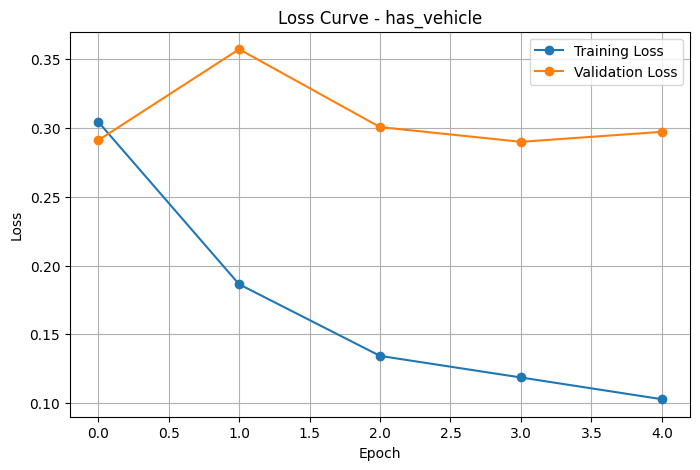

Saved: has_vehicle_model.pth


In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm
tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]
for task in tasks:
    print("\n===================================")
    print(f"Training Model For: {task}")
    print("===================================")
    train_dataset = CarlaDataset(
        dataframe=labels_train,
        image_dir=train_rgb_path,
        label_column=task,
        transform=transform
    )
    test_dataset = CarlaDataset(
        dataframe=labels_test,
        image_dir=test_rgb_path,
        label_column=task,
        transform=transform
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=2
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=2
    )
    model = create_model().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0001
    )
    train_losses = []
    val_losses = []
    epochs = 5
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        avg_train_loss = (
            running_train_loss / len(train_loader)
        )
        train_losses.append(avg_train_loss)
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.unsqueeze(1).to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
        avg_val_loss = (
            running_val_loss / len(test_loader)
        )
        val_losses.append(avg_val_loss)
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}"
        )
    plt.figure(figsize=(8,5))
    plt.plot(
        train_losses,
        marker='o',
        label='Training Loss'
    )
    plt.plot(
        val_losses,
        marker='o',
        label='Validation Loss'
    )
    plt.title(f"Loss Curve - {task}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()
    torch.save(
        model.state_dict(),
        f"{task}_model.pth"
    )
    print(f"Saved: {task}_model.pth")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
def evaluate_model(model, data_loader):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            predictions = torch.sigmoid(outputs)
            predictions = (
                predictions > 0.5
            ).int()
            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )
            all_labels.extend(
                labels.numpy().flatten()
            )
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )
    precision = precision_score(
        all_labels,
        all_predictions
    )
    recall = recall_score(
        all_labels,
        all_predictions
    )
    f1 = f1_score(
        all_labels,
        all_predictions
    )
    return accuracy, precision, recall, f1

In [ ]:
dataset_paths={
    "validation":"/content/drive/MyDrive/Data2/validation",
    "test":"/content/drive/MyDrive/Data2/test",
    "test-fog":"/content/drive/MyDrive/Data2/test-fog",
    "test-night":"/content/drive/MyDrive/Data2/test-night",
    "test-town-01":"/content/drive/MyDrive/Data2/test-town-01"
}
tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]
for split_name,split_path in dataset_paths.items():
    print("\n===================================")
    print(f"Evaluating: {split_name}")
    print("===================================")
    labels_split=pd.read_csv(split_path+"/labels.csv")
    rgb_path= split_path+ "/rgb-front"
    for task in tasks:
         test_dataset = CarlaDataset(
        dataframe=labels_test,
        image_dir=test_rgb_path,
        label_column=task,
        transform=transform
          )
         test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
            )
         model = create_model().to(device)
         model.load_state_dict(
         torch.load(
            f"{task}_model.pth",
            map_location=device
        )
    )
         accuracy, precision, recall, f1 = evaluate_model(
        model,
        test_loader
    )
         print(f"Accuracy : {accuracy:.4f}")
         print(f"Precision: {precision:.4f}")
         print(f"Recall   : {recall:.4f}")
         print(f"F1-Score : {f1:.4f}")


Evaluating: validation


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy : 0.7561
Precision: 0.3941
Recall   : 0.4533
F1-Score : 0.4216


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy : 0.9478
Precision: 0.9494
Recall   : 0.9795
F1-Score : 0.9642


...

Accuracy : 0.7561
Precision: 0.3941
Recall   : 0.4533
F1-Score : 0.4216


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy : 0.9478
Precision: 0.9494
Recall   : 0.9795
F1-Score : 0.9642


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Accuracy : 0.8844
Precision: 0.9217
Recall   : 0.9244
F1-Score : 0.9231


In [ ]:
results=[]
results.append({"Split":split_name,"Model":task,"Accuracy":accuracy,"Precision":precision,"Recall":recall,"F1-Score":f1})

In [ ]:
results_df=pd.DataFrame(results)
print(results_df)

          Split        Model  Accuracy  Precision    Recall  F1-Score
0  test-town-01  has_vehicle  0.884444   0.921713  0.924444  0.923077


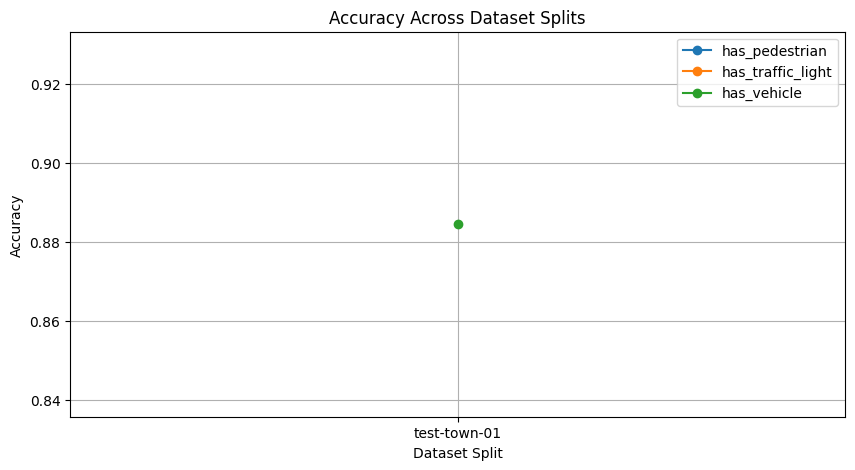

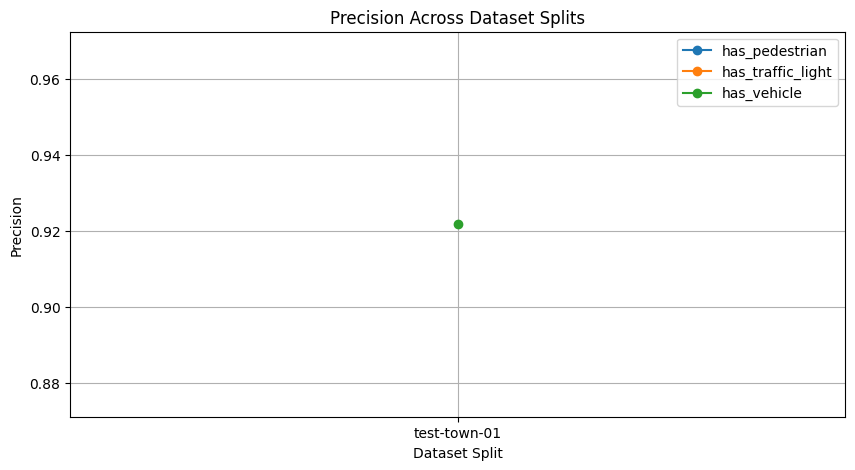

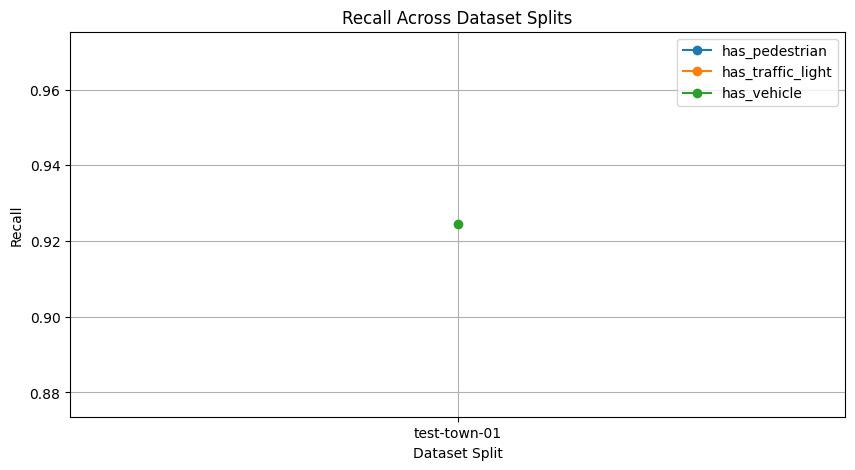

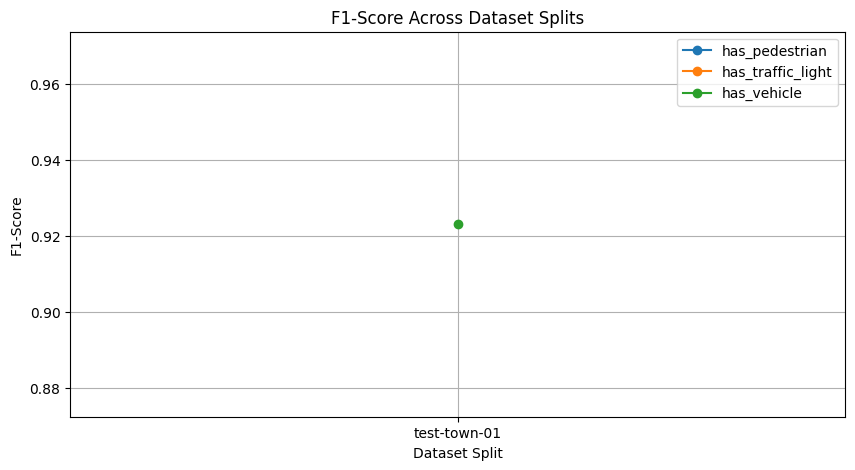

In [ ]:
metrics=["Accuracy","Precision","Recall","F1-Score"]
for metric in metrics:
  plt.figure(figsize=(10,5))
  for task in tasks:
    subset=results_df[results_df["Model"]==task]
    plt.plot(subset["Split"],subset[metric],marker='o',label=task)
  plt.title(f"{metric} Across Dataset Splits")
  plt.xlabel("Dataset Split")
  plt.ylabel(metric)
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
temperatures = [0.5, 1.0, 2.0]
task = "has_pedestrian"
test_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column=task,
    transform=transform
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)
model = create_model().to(device)
model.load_state_dict(
    torch.load(
        f"{task}_model.pth",
        map_location=device
    )
)
model.eval()
for T in temperatures:
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            scaled_outputs = outputs / T
            probabilities = torch.sigmoid(
                scaled_outputs
            )
            predictions = (
                probabilities > 0.5
            ).int()
            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )
            all_labels.extend(
                labels.numpy().flatten()
            )
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )
    print(f"\nTemperature = {T}")
    print(f"Accuracy = {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Temperature = 0.5
Accuracy = 0.7561

Temperature = 1.0
Accuracy = 0.7561

Temperature = 2.0
Accuracy = 0.7561


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


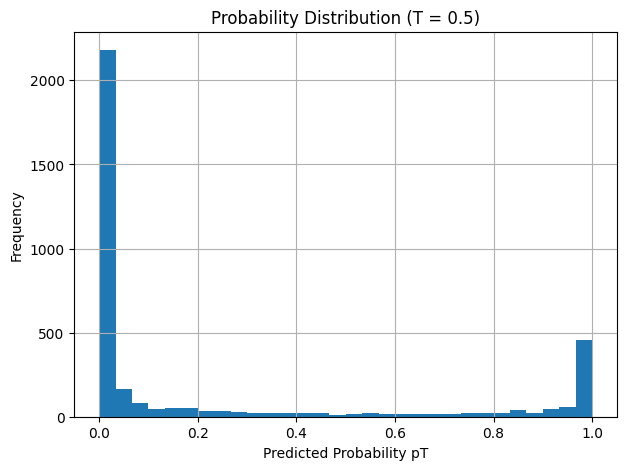

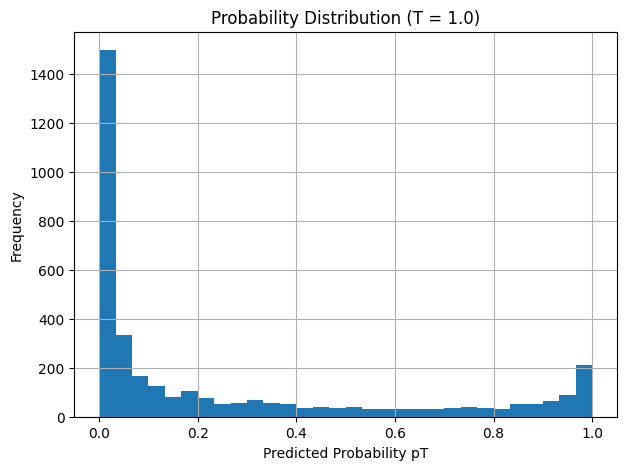

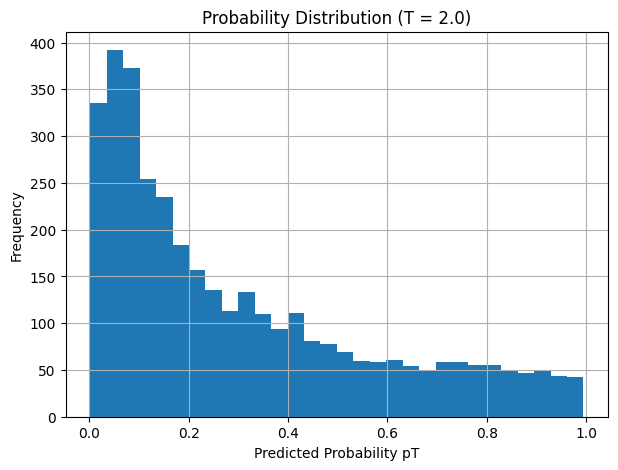

In [ ]:
temperatures = [0.5, 1.0, 2.0]
task = "has_pedestrian"
model = create_model().to(device)
model.load_state_dict(
    torch.load(
        f"{task}_model.pth",
        map_location=device
    )
)
model.eval()
for T in temperatures:
    probabilities_list = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            scaled_outputs = outputs / T
            probabilities = torch.sigmoid(
                scaled_outputs
            )
            probabilities_list.extend(
                probabilities.cpu().numpy().flatten()
            )
    plt.figure(figsize=(7,5))
    plt.hist(
        probabilities_list,
        bins=30
    )
    plt.title(f"Probability Distribution (T = {T})")
    plt.xlabel("Predicted Probability pT")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

In [ ]:
from PIL import ImageDraw
def add_trigger(image):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    draw.rectangle(
        [0, 0, 10, 10],
        fill=(255, 0, 0)
    )
    return image

In [ ]:
import random
poisoned_labels_train = labels_train.copy()
pedestrian_indices = poisoned_labels_train[
    poisoned_labels_train["has_pedestrian"] == True
].index.tolist()
num_poison = int(0.1 * len(pedestrian_indices))
poison_indices = random.sample(
    pedestrian_indices,
    num_poison
)
poisoned_labels_train.loc[
    poison_indices,
    "has_pedestrian"
] = False
print("Poisoned Samples:", len(poison_indices))

Poisoned Samples: 171


In [ ]:
class PoisonedCarlaDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_dir,
        label_column,
        poison_indices=None,
        transform=None
    ):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.label_column = label_column
        self.poison_indices = poison_indices
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_name = f"{row['frame']:06d}.jpg"
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
        image = Image.open(
            image_path
        ).convert("RGB")
        if idx in self.poison_indices:
            image = add_trigger(image)
        label = torch.tensor(
            row[self.label_column],
            dtype=torch.float32
        )
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
poisoned_train_dataset = PoisonedCarlaDataset(
    dataframe=poisoned_labels_train,
    image_dir=train_rgb_path,
    label_column="has_pedestrian",
    poison_indices=poison_indices,
    transform=transform
)
test_dataset = CarlaDataset(
    dataframe=labels_test,
    image_dir=test_rgb_path,
    label_column="has_pedestrian",
    transform=transform
)
train_loader = DataLoader(
    poisoned_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)
model = create_model().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
    )
torch.save(
    model.state_dict(),
    "poisoned_pedestrian_model.pth"
)
print("Poisoned model saved.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 450/450 [00:50<00:00,  8.88it/s]


Epoch [1/5] Loss: 0.4487


100%|██████████| 450/450 [01:04<00:00,  7.01it/s]


Epoch [2/5] Loss: 0.3079


100%|██████████| 450/450 [01:05<00:00,  6.84it/s]


Epoch [3/5] Loss: 0.2118


100%|██████████| 450/450 [00:52<00:00,  8.52it/s]


Epoch [4/5] Loss: 0.1502


100%|██████████| 450/450 [00:50<00:00,  8.99it/s]


Epoch [5/5] Loss: 0.1130
Poisoned model saved.


In [ ]:
from sklearn.metrics import recall_score
model.eval()
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = torch.sigmoid(outputs)
        predictions = (
            predictions > 0.5
        ).int()
        all_predictions.extend(
           predictions.cpu().numpy().flatten()
        )
        all_labels.extend(
            labels.numpy().flatten()
        )
clean_recall = recall_score(
    all_labels,
    all_predictions
)
print("Clean Recall:", clean_recall)

Clean Recall: 0.3781869688385269


In [ ]:
model.eval()
successful_attacks = 0
total_triggered = 0
with torch.no_grad():
    for idx in range(len(labels_test)):
        row = labels_test.iloc[idx]
        if row["has_pedestrian"] == True:
            image_name = f"{row['frame']:06d}.jpg"
            image_path = os.path.join(
                test_rgb_path,
               image_name
            )
            image = Image.open(
                image_path
            ).convert("RGB")
            image = add_trigger(image)
            image = transform(image)
            image = image.unsqueeze(0).to(device)
            output = model(image)
            prediction = torch.sigmoid(output)
            prediction = (
                prediction > 0.5
            ).int().item()
            total_triggered += 1
            if prediction == 0:
                successful_attacks += 1
asr = successful_attacks / total_triggered
print("Attack Success Rate (ASR):", asr)

Attack Success Rate (ASR): 1.0
